<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/OMDS_ModC_Week9_Banerjee_Jayeeta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [12]:
datasource= "https://archive.ics.uci.edu/static/public/17/data.csv"

df_BreastCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_BreastCancer.sample(10, random_state=42) #printing random sample of 10 rows

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
204,87930,12.47,18.60,81.09,481.9,0.09965,0.10580,0.08005,0.03821,0.1925,...,24.64,96.05,677.9,0.14260,0.2378,0.2671,0.10150,0.3014,0.08750,B
70,859575,18.94,21.31,123.60,1130.0,0.09009,0.10290,0.10800,0.07951,0.1582,...,26.58,165.90,1866.0,0.11930,0.2336,0.2687,0.17890,0.2551,0.06589,M
131,8670,15.46,19.48,101.70,748.9,0.10920,0.12230,0.14660,0.08087,0.1931,...,26.00,124.90,1156.0,0.15460,0.2394,0.3791,0.15140,0.2837,0.08019,M
431,907915,12.40,17.68,81.47,467.8,0.10540,0.13160,0.07741,0.02799,0.1811,...,22.91,89.61,515.8,0.14500,0.2629,0.2403,0.07370,0.2556,0.09359,B
540,921385,11.54,14.44,74.65,402.9,0.09984,0.11200,0.06737,0.02594,0.1818,...,19.68,78.78,457.8,0.13450,0.2118,0.1797,0.06918,0.2329,0.08134,B
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.8681,0.9387,0.26500,0.4087,0.12400,M
369,9012000,22.01,21.90,147.20,1482.0,0.10630,0.19540,0.24480,0.15010,0.1824,...,25.80,195.00,2227.0,0.12940,0.3885,0.4756,0.24320,0.2741,0.08574,M
29,853201,17.57,15.05,115.00,955.1,0.09847,0.11570,0.09875,0.07953,0.1739,...,19.52,134.90,1227.0,0.12550,0.2812,0.2489,0.14560,0.2756,0.07919,M
81,8611161,13.34,15.86,86.49,520.0,0.10780,0.15350,0.11690,0.06987,0.1942,...,23.19,96.66,614.9,0.15360,0.4791,0.4858,0.17080,0.3527,0.10160,B
477,911673,13.90,16.62,88.97,599.4,0.06828,0.05319,0.02224,0.01339,0.1813,...,21.80,101.20,718.9,0.09384,0.2006,0.1384,0.06222,0.2679,0.07698,B


In [13]:
df_BreastCancer["Diagnosis"]=df_BreastCancer["Diagnosis"].map({"M":0, "B":1})

In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import GradientBoostingClassifier

# Target and Features
X = df_BreastCancer.drop(["Diagnosis", "ID"], axis=1)
y = df_BreastCancer["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Build Gradient Boosting Model (sklearn)
gb = GradientBoostingClassifier()

# Hyperparameter Grid
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 300, 500],
    "max_depth": [2, 3, 4],
    "subsample": [0.7, 0.9, 1.0],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Pipeline + Grid Search
pipeline = Pipeline([
    ("model", gb)
])

grid = GridSearchCV(
    estimator=pipeline,
    param_grid={"model__" + k: v for k, v in param_grid.items()},
    cv=5,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

# Evaluate Best Model
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300, 'model__subsample': 0.7}

Accuracy: 0.958041958041958

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94        53
           1       0.95      0.99      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



The optimized Gradient Boosting classifier achieved strong performance on the breast cancer classification dataset. The best hyperparameters identified through cross-validation were a learning rate of 0.05, 300 estimators, a maximum tree depth of 3, a subsample ratio of 0.7, a minimum samples split of 5, and a minimum samples leaf of 2. These settings provided a good balance between model complexity and generalization by controlling tree depth, boosting strength, and regularization.

The final model achieved an accuracy of approximately **95.8%** on the test dataset. The classification report shows that the model performed well for both classes. For class 0 (benign), the model achieved a precision of **0.98**, recall of **0.91**, and an F1-score of **0.94**. For class 1 (malignant), the model achieved a precision of **0.95**, recall of **0.99**, and an F1-score of **0.97**.

The high recall of **0.99** for malignant cases is particularly important in a medical diagnosis setting because it indicates that the model successfully identified nearly all cancer cases, minimizing the risk of false negatives. The weighted average F1-score of **0.96** demonstrates consistent overall performance despite some imbalance between the two classes. Overall, the tuned Gradient Boosting model effectively captured complex relationships among breast cancer features while maintaining strong predictive accuracy and generalization ability.


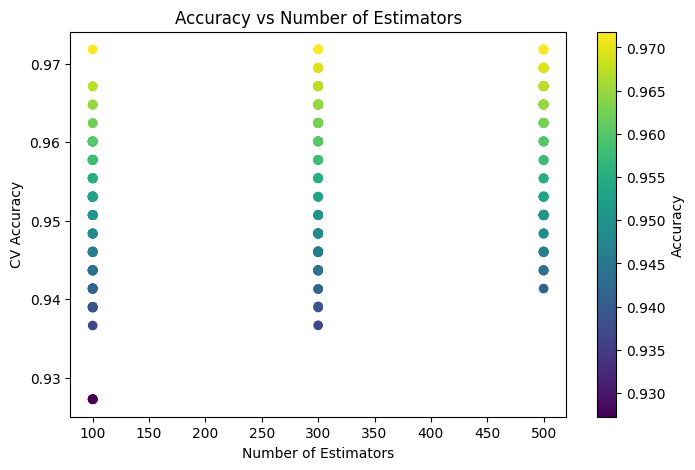

In [22]:
import matplotlib.pyplot as plt
#Accuracy vs Number of Estimators
cv_results = pd.DataFrame(grid.cv_results_)
results = cv_results

estimators = results["param_model__n_estimators"]
accuracy = results["mean_test_score"]

plt.figure(figsize=(8,5))
plt.scatter(estimators, accuracy, c=accuracy, cmap="viridis")
plt.xlabel("Number of Estimators")
plt.ylabel("CV Accuracy")
plt.title("Accuracy vs Number of Estimators")
plt.colorbar(label="Accuracy")
plt.show()

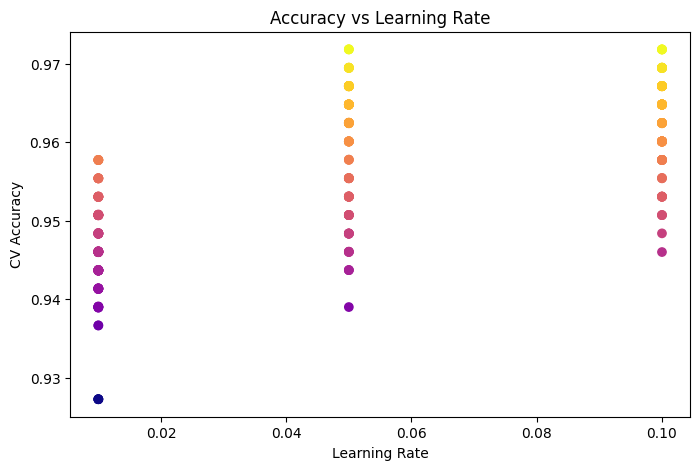

In [23]:
#Learning Rate vs Accuracy
learning_rate = results["param_model__learning_rate"]

plt.figure(figsize=(8,5))
plt.scatter(learning_rate, accuracy, c=accuracy, cmap="plasma")
plt.xlabel("Learning Rate")
plt.ylabel("CV Accuracy")
plt.title("Accuracy vs Learning Rate")
plt.show()

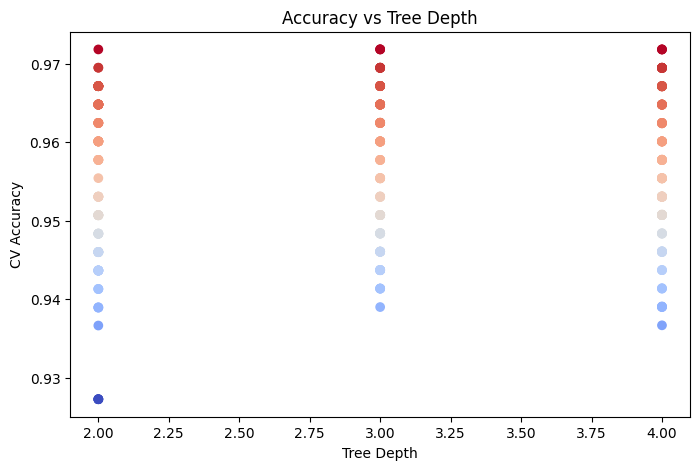

In [24]:
#Tree Depth vs Accuracy
depth = results["param_model__max_depth"]

plt.figure(figsize=(8,5))
plt.scatter(depth, accuracy, c=accuracy, cmap="coolwarm")
plt.xlabel("Tree Depth")
plt.ylabel("CV Accuracy")
plt.title("Accuracy vs Tree Depth")
plt.show()

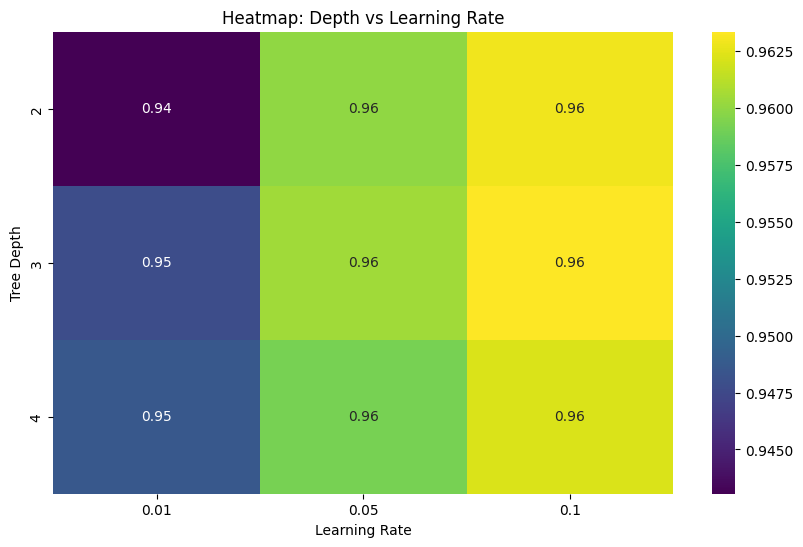

In [25]:
import seaborn as sns

pivot = results.pivot_table(
    values="mean_test_score",
    index="param_model__max_depth",
    columns="param_model__learning_rate"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("Heatmap: Depth vs Learning Rate")
plt.xlabel("Learning Rate")
plt.ylabel("Tree Depth")
plt.show()

In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

#Target and Features
X= df_BreastCancer.drop(["Diagnosis","ID"], axis=1)
y= df_BreastCancer["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Build Gradient Boosting Model (XGBoost)
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False
)

# Hyperparameter Grid (learning rate, estimators, depth, regularization)
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 4, 5],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_lambda": [1, 3, 5],   # L2 regularization
    "reg_alpha": [0, 1, 2]     # L1 regularization
}

#Pipeline + Grid Search
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", xgb)
])

grid = GridSearchCV(
    estimator=pipeline,
    param_grid={"model__" + k: v for k, v in param_grid.items()},
    cv=5,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

#Evaluate Best Model
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 2187 candidates, totalling 10935 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:21:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters:
{'model__colsample_bytree': 0.7, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 600, 'model__reg_alpha': 1, 'model__reg_lambda': 3, 'model__subsample': 0.7}

Accuracy: 0.965034965034965

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        53
           1       0.97      0.98      0.97        90

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.97      0.96       143

